# TensorFlow를 활용한 선형회귀 실습

이 노트북에서는 TensorFlow를 사용하여 간단한 선형회귀 문제를 풀어봅니다.

## 주요 단계
1. 데이터 생성 (y = 3x + 2 + 잡음)
2. 모델 정의 (Dense Layer)
3. 손실 함수 및 최적화 방법 설정
4. 학습 진행 및 시각화


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

I0000 00:00:1789468976.432324 1200959 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789468976.813744 1200959 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789468978.158725 1200959 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2.21.0


## 1. 데이터 생성

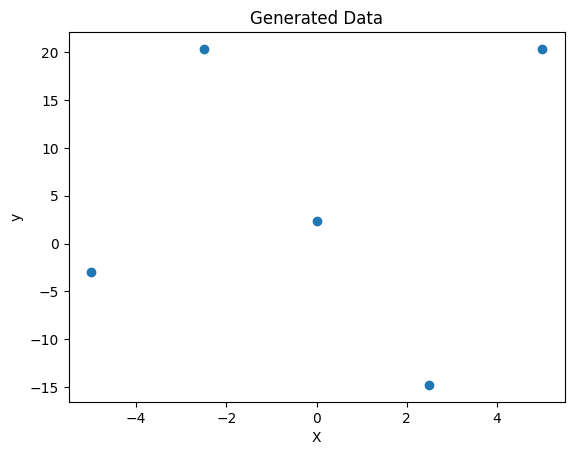

In [2]:
# y = 3x + 2 + noise
n_samples = 5
X = np.linspace(-5, 5, n_samples)
y = 3 * X + 2 + np.random.normal(0, 1, n_samples)*20

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Generated Data")
plt.show()

## 2. 모델 정의

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(1,)),
    tf.keras.layers.Dense(1)
])

model.summary()

W0000 00:00:1789468997.733890 1200959 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. 모델 컴파일
- 손실 함수: MSE (Mean Squared Error)
- 최적화 방법: SGD (Stochastic Gradient Descent)

In [4]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='mse')

## 4. 모델 학습

Epoch 1/200
1/1 - 0s - 151ms/step - loss: 259.5895
Epoch 2/200
1/1 - 0s - 22ms/step - loss: 236.6465
Epoch 3/200
1/1 - 0s - 22ms/step - loss: 223.3393
Epoch 4/200
1/1 - 0s - 26ms/step - loss: 215.4681
Epoch 5/200
1/1 - 0s - 22ms/step - loss: 210.6700
Epoch 6/200
1/1 - 0s - 22ms/step - loss: 207.6152
Epoch 7/200
1/1 - 0s - 25ms/step - loss: 205.5550
Epoch 8/200
1/1 - 0s - 24ms/step - loss: 204.0679
Epoch 9/200
1/1 - 0s - 25ms/step - loss: 202.9161
Epoch 10/200
1/1 - 0s - 23ms/step - loss: 201.9655
Epoch 11/200
1/1 - 0s - 22ms/step - loss: 201.1399
Epoch 12/200
1/1 - 0s - 25ms/step - loss: 200.3962
Epoch 13/200
1/1 - 0s - 23ms/step - loss: 199.7097
Epoch 14/200
1/1 - 0s - 22ms/step - loss: 199.0660
Epoch 15/200
1/1 - 0s - 22ms/step - loss: 198.4565
Epoch 16/200
1/1 - 0s - 22ms/step - loss: 197.8760
Epoch 17/200
1/1 - 0s - 22ms/step - loss: 197.3213
Epoch 18/200
1/1 - 0s - 22ms/step - loss: 196.7901
Epoch 19/200
1/1 - 0s - 23ms/step - loss: 196.2808
Epoch 20/200
1/1 - 0s - 25ms/step - los

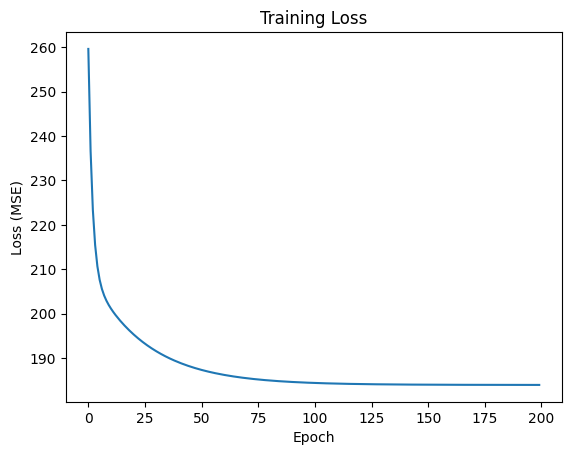

In [5]:
history = model.fit(X, y, epochs=200, verbose=2)

plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss')
plt.show()

## 5. 결과 확인

학습된 기울기 W: 0.458, 절편 b: 4.961
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


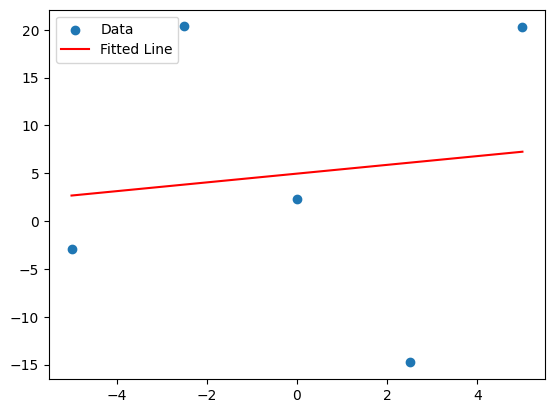

In [6]:
W, b = model.layers[0].get_weights()
print(f"학습된 기울기 W: {W[0][0]:.3f}, 절편 b: {b[0]:.3f}")

y_pred = model.predict(X)

plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Fitted Line')
plt.legend()
plt.show()

## 생각해보기
- 학습 샘플 수가 작아지면 어떻게 되는가?

학습이 제대로 안돼서 예측의 정확도가 떨어질것 같다.

- 학습 샘플에 잡음이 많으면 어떻게 되는가? 이 경우 학습 데이터가 많이 필요한가?

데이터가 크게 벗어나 정확한 관계를 학습하기 어려워집니다. 더 많은 학습 데이터가 필요합니다.